# Engine Degradation Pattern Analysis

## Objective

The purpose of this notebook is to investigate how sensor measurements evolve throughout an engine's lifetime.

Since different engines fail after different numbers of cycles, comparing raw cycle numbers is misleading.

To overcome this limitation, each engine's lifetime is normalized to a percentage scale ranging from 0% (new engine) to 100% (failure).

This notebook answers the following questions:

- Which sensors exhibit clear degradation trends?
- Which sensors remain stable?
- Which sensors become unstable near failure?
- Which sensors should receive higher priority during feature engineering?

In [ ]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent

sys.path.append(str(PROJECT_ROOT))

print(PROJECT_ROOT)

A:\AI Engineer in the way\ML Projects\Predictive-Maintenance-RUL


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.data.loader import DataLoader
from src.data.validator import DataValidator
from src.config.config import (
    TRAIN_DATA_PATH,
    TEST_DATA_PATH,
    RUL_DATA_PATH,
)

In [3]:
loader = DataLoader(
    TRAIN_DATA_PATH,
    TEST_DATA_PATH,
    RUL_DATA_PATH
)

train_df = loader.load_train()
test_df = loader.load_test()
rul_df = loader.load_rul()

validator = DataValidator(
    train_df,
    test_df,
    rul_df
)

validator.validate_all()

2026-07-21 10:27:56 | INFO | loader.py | Line:18 | Reading train_FD004.txt
2026-07-21 10:27:59 | INFO | loader.py | Line:21 | train_FD004.txt Loaded Successfully
2026-07-21 10:27:59 | INFO | loader.py | Line:18 | Reading test_FD004.txt
2026-07-21 10:28:01 | INFO | loader.py | Line:21 | test_FD004.txt Loaded Successfully
2026-07-21 10:28:01 | INFO | loader.py | Line:18 | Reading RUL_FD004.txt
2026-07-21 10:28:01 | INFO | loader.py | Line:21 | RUL_FD004.txt Loaded Successfully
2026-07-21 10:28:01 | INFO | validator.py | Line:40 | Validating training dataset...
2026-07-21 10:28:01 | INFO | validator.py | Line:50 | Validating testing dataset...
2026-07-21 10:28:01 | INFO | validator.py | Line:60 | Validating RUL dataset...


{'train': {'valid': True, 'errors': [], 'warnings': []},
 'test': {'valid': True, 'errors': [], 'warnings': []},
 'rul': {'valid': True, 'errors': [], 'warnings': ['Duplicate rows found.']}}

### Compute Engine Lifetime

In [28]:
engine_max_cycle = (
    train_df
    .groupby("unit_number")["time_in_cycles"]
    .transform("max")
)

In [29]:
eda_df = train_df.copy()

eda_df["life_percentage"] = (
    eda_df["time_in_cycles"] /
    engine_max_cycle
)

In [30]:
eda_df["life_stage"] = pd.cut(
    eda_df["life_percentage"],
    bins=20,
    labels=False
)

In [31]:
sensor_columns = [
    c
    for c in eda_df.columns
    if c.startswith("sensor")
]

sensor_stage_mean = (
    eda_df
    .groupby("life_stage")[sensor_columns]
    .mean()
)

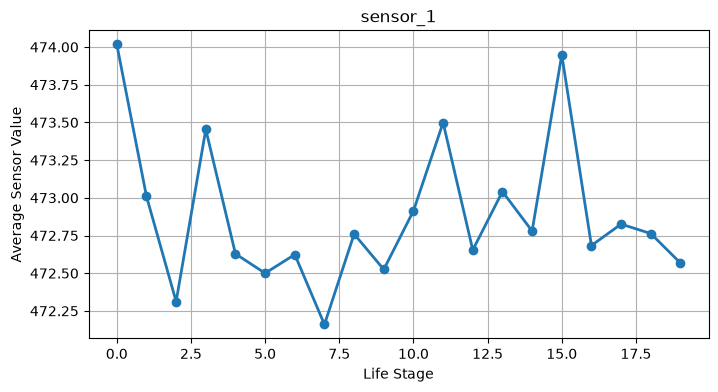

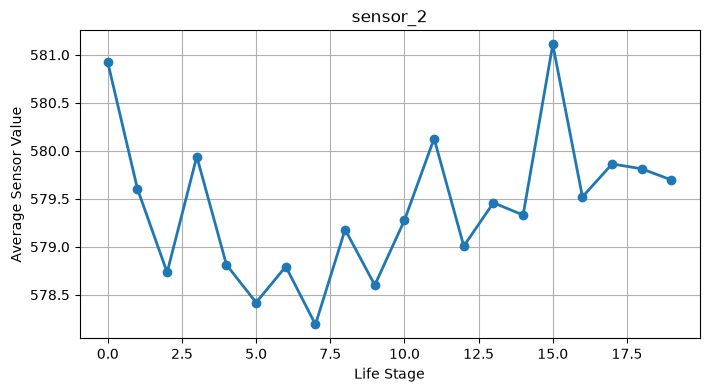

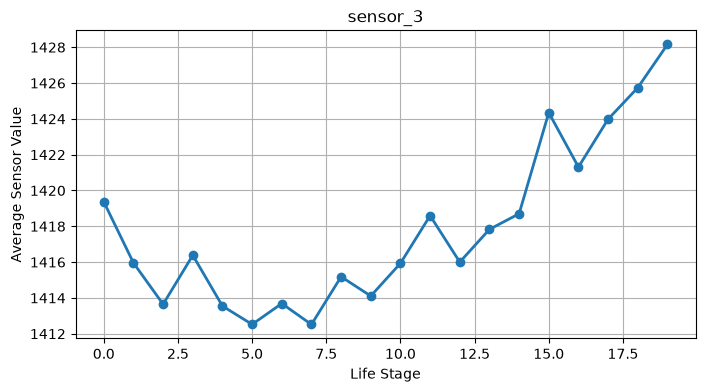

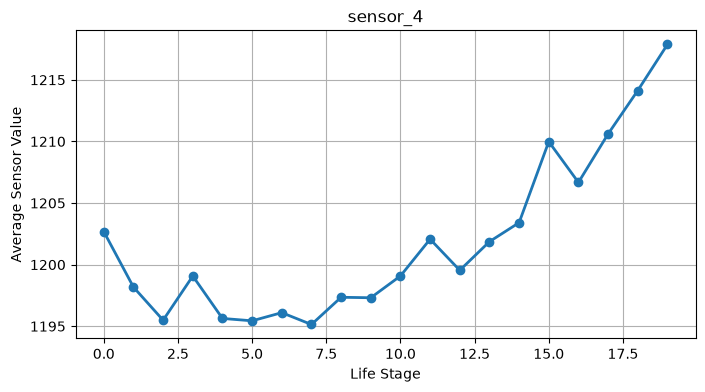

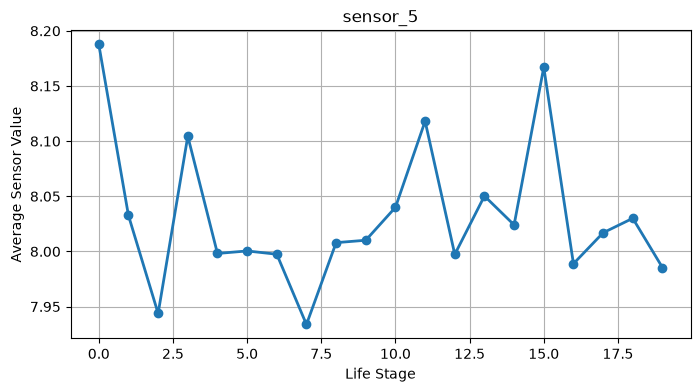

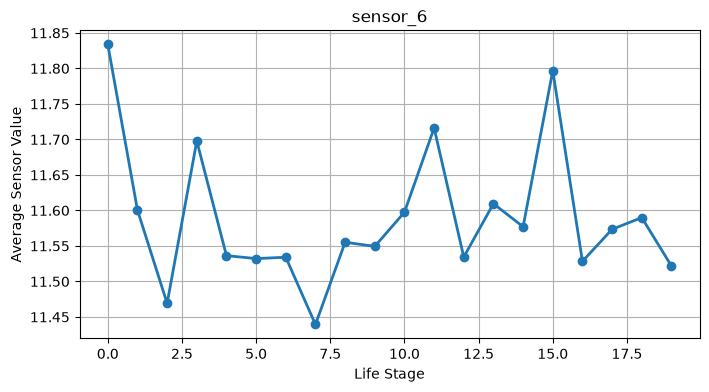

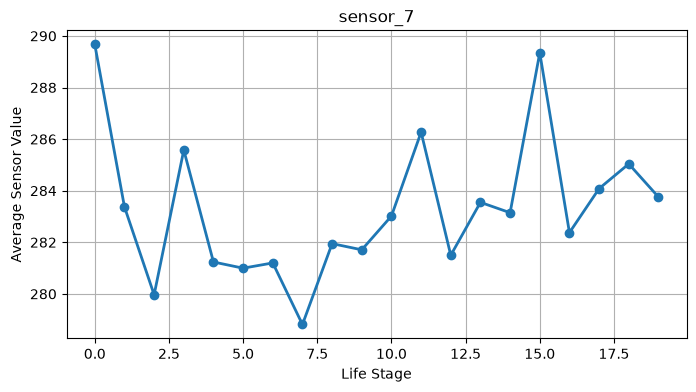

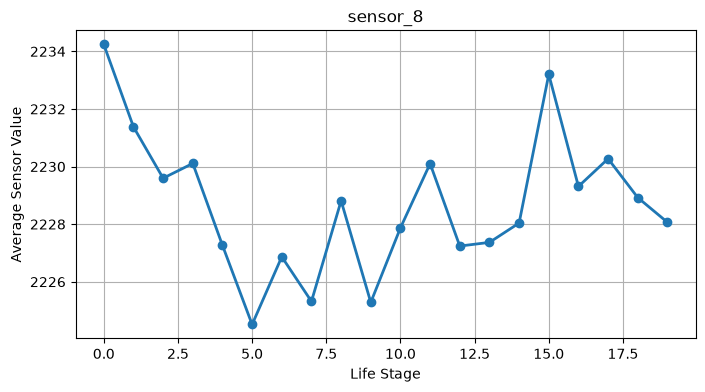

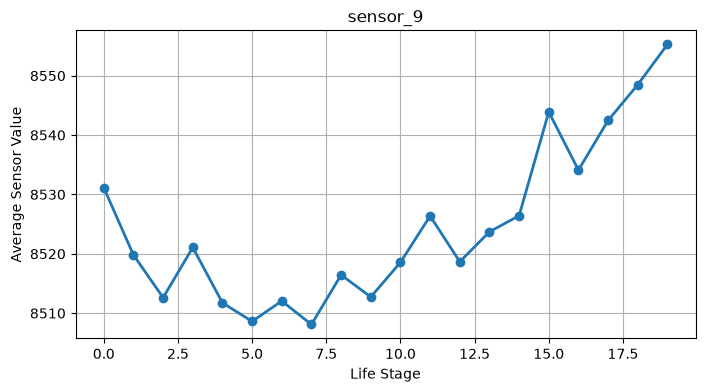

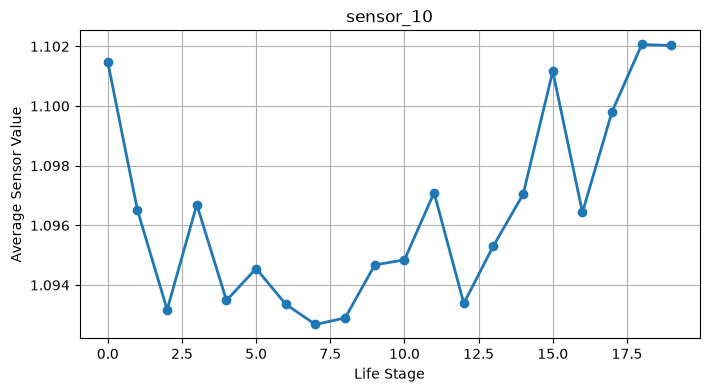

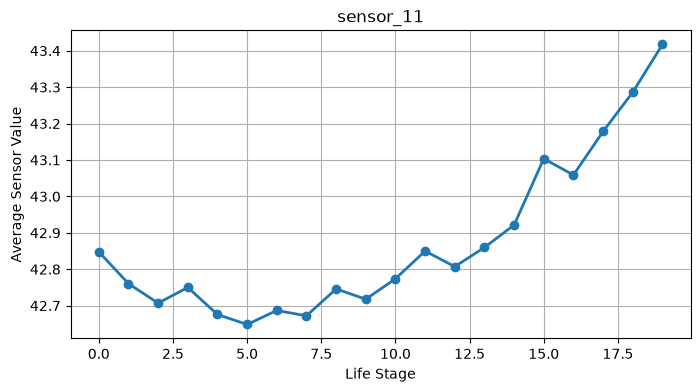

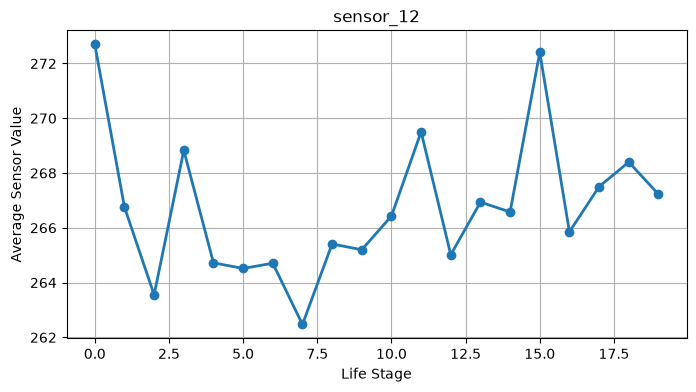

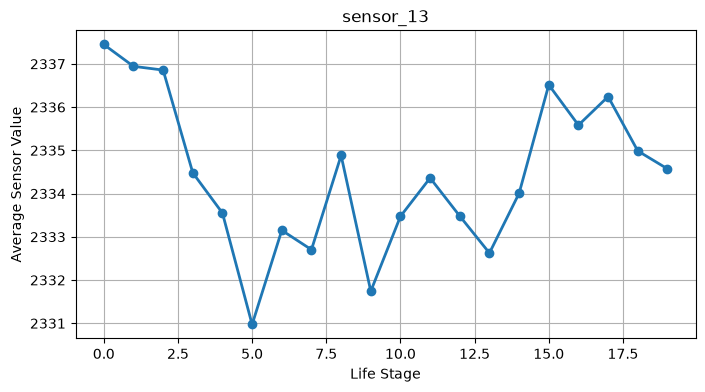

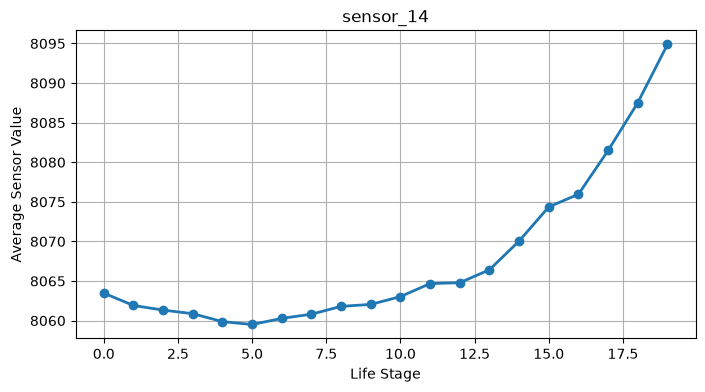

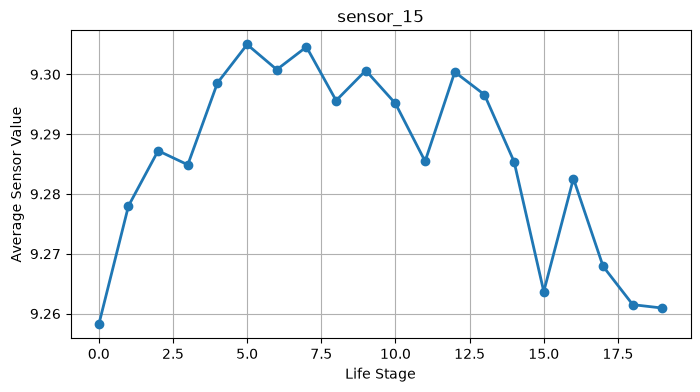

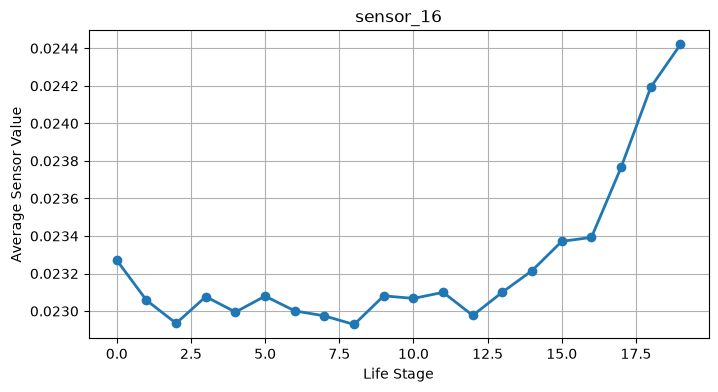

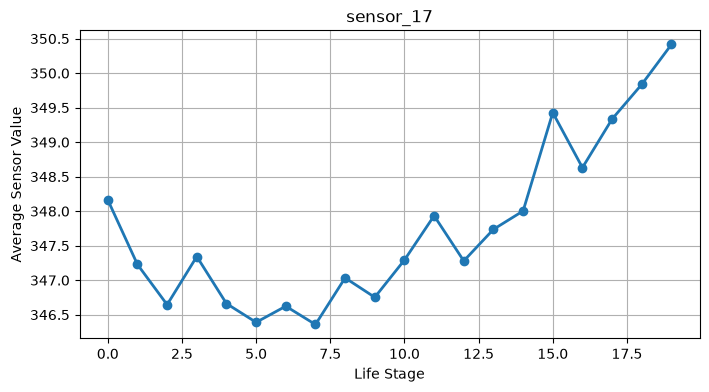

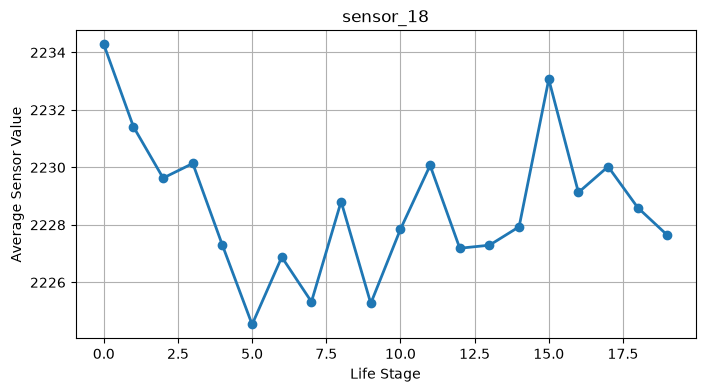

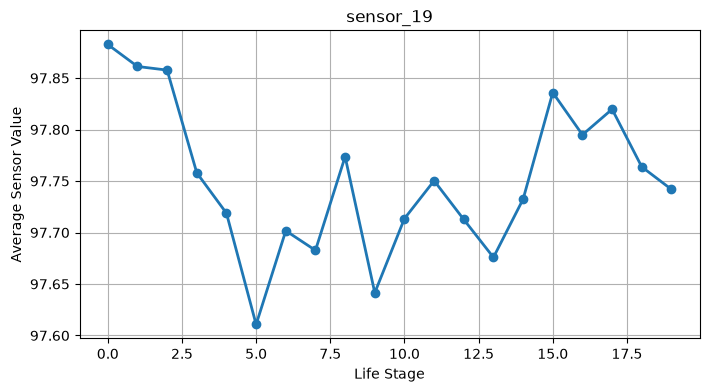

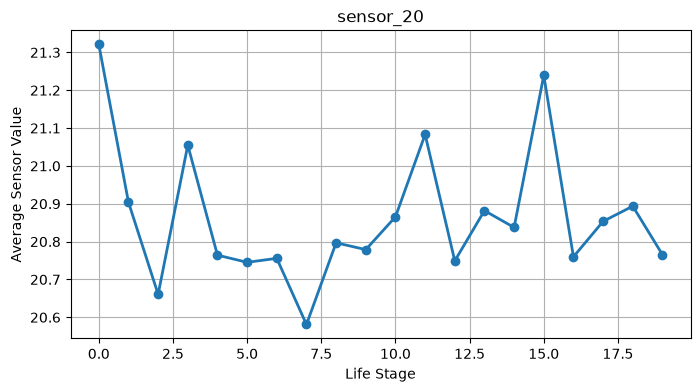

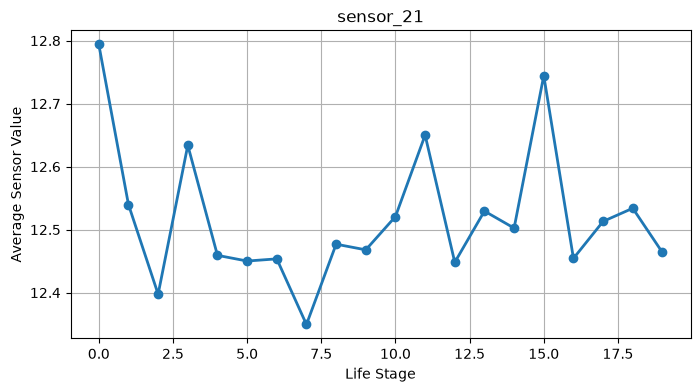

In [ ]:
for sensor in sensor_columns:

    plt.figure(figsize=(8,4))

    plt.plot(
        sensor_stage_mean.index,
        sensor_stage_mean[sensor],
        linewidth=2,
        marker="o"
    )

    plt.title(sensor)
    plt.xlabel("Life Stage")
    plt.ylabel("Average Sensor Value")
    plt.grid(True)
    plt.show()

#### Normalize Sensor Values 

Since sensors use different units, normalize them before comparing trends.

In [33]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

normalized = eda_df.copy()

normalized[sensor_columns] = scaler.fit_transform(
    normalized[sensor_columns]
)

normalized_stage = (
    normalized
    .groupby("life_stage")[sensor_columns]
    .mean()
)

In [34]:
important = [
    "sensor_7",
    "sensor_8",
    "sensor_9",
    "sensor_11",
    "sensor_12",
    "sensor_14",
]

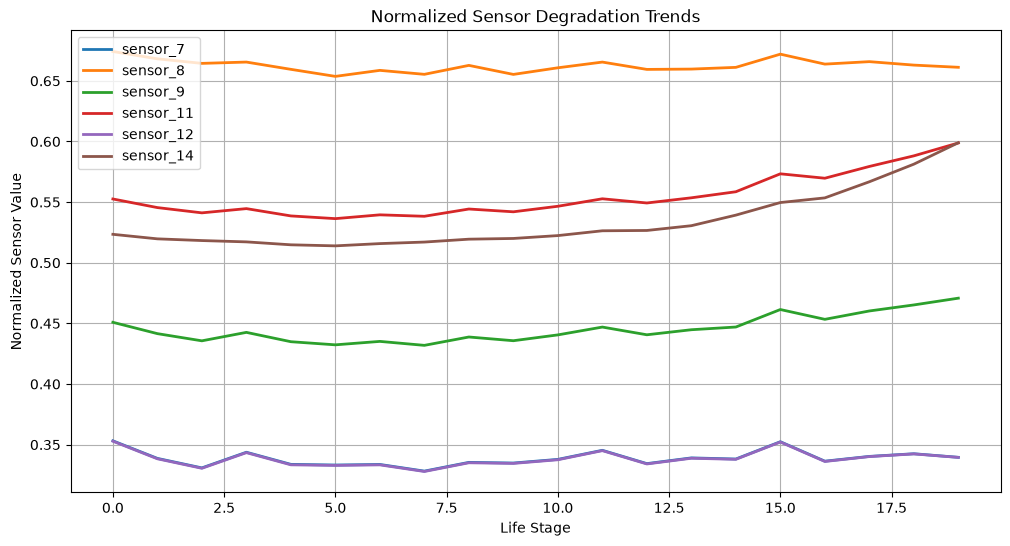

In [ ]:
plt.figure(figsize=(12,6))

for sensor in important:

    plt.plot(
        normalized_stage.index,
        normalized_stage[sensor],
        linewidth=2,
        label=sensor
    )

plt.title("Normalized Sensor Degradation Trends")
plt.xlabel("Life Stage")
plt.ylabel("Normalized Sensor Value")
plt.legend()
plt.grid(True)
plt.show()

In [37]:
trend_summary = pd.DataFrame({
    "Start": normalized_stage.iloc[0],
    "End": normalized_stage.iloc[-1],
})

trend_summary["Change"] = (
    trend_summary["End"] - trend_summary["Start"]
)

trend_summary["Absolute Change"] = (
    trend_summary["Change"].abs()
)

trend_summary["Direction"] = np.where(
    trend_summary["Change"] > 0,
    "Increasing",
    "Decreasing"
)

trend_summary = trend_summary.sort_values(
    "Absolute Change",
    ascending=False
)
trend_summary

,Start,End,Change,Absolute Change,Direction
sensor_16,0.327081,0.442006,0.114925,0.114925,Increasing
sensor_14,0.523450,0.598971,0.075521,0.075521,Increasing
sensor_11,0.552589,0.598791,0.046202,0.046202,Increasing
sensor_4,0.428155,0.464625,0.036470,0.036470,Increasing
sensor_3,0.477130,0.500857,0.023727,0.023727,Increasing
sensor_17,0.475913,0.499127,0.023215,0.023215,Increasing
sensor_9,0.450897,0.470796,0.019899,0.019899,Increasing
sensor_1,0.393873,0.374204,-0.019669,0.019669,Decreasing
sensor_6,0.386680,0.367116,-0.019564,0.019564,Decreasing
sensor_5,0.399404,0.380528,-0.018876,0.018876,Decreasing


# Observations

## Overall Sensor Behavior

The normalized lifecycle analysis compared the average sensor values at the beginning and end of an engine's life.

The majority of sensors exhibit relatively small changes throughout the engine lifecycle, suggesting that degradation is generally subtle rather than abrupt.

---

## Sensors with the Largest Changes

The following sensors showed the greatest overall change:

| Sensor | Absolute Change |
|--------|----------------:|
| Sensor 16 | 0.115 |
| Sensor 14 | 0.076 |
| Sensor 11 | 0.046 |
| Sensor 4 | 0.036 |
| Sensor 3 | 0.024 |

These sensors are the strongest initial candidates for degradation monitoring.

---

## Moderately Changing Sensors

Several sensors exhibit moderate but noticeable changes during engine operation, including:

- Sensor 17
- Sensor 9
- Sensor 1
- Sensor 6
- Sensor 5
- Sensor 20
- Sensor 21

These sensors may still provide useful predictive information when combined with other features.

---

## Nearly Stable Sensors

Some sensors show almost no change across the engine lifecycle.

Examples include:

- Sensor 10
- Sensor 15
- Sensor 13
- Sensor 19

These sensors appear relatively stable during normal engine operation.

However, stability alone does not imply that a sensor is uninformative. Further analyses are required before making feature selection decisions.

---

## Interpretation

The observed changes indicate that degradation is distributed across multiple sensors rather than being dominated by a single measurement.

This suggests that Remaining Useful Life prediction will likely benefit from combining information from multiple sensors instead of relying on any individual feature.

# Engineering Decisions

## Decision 1 — Prioritize High-Change Sensors

Sensors exhibiting the largest lifecycle changes (e.g., Sensors 16, 14, and 11) will receive higher priority during subsequent degradation analysis and feature engineering.

---

## Decision 2 — Preserve Moderate-Change Sensors

Sensors with moderate lifecycle changes will remain part of the feature set, as machine learning models may capture interactions that are not evident from individual sensor trends.

---

## Decision 3 — Do Not Remove Stable Sensors Yet

Sensors with minimal lifecycle changes (e.g., Sensors 10 and 15) will not be removed at this stage.

Their predictive value will be reassessed after correlation analysis and model-based feature importance evaluation.

---

## Decision 4 — Use Multiple Evaluation Criteria

Feature selection will not rely solely on lifecycle change.

Future decisions will combine evidence from:

- Variance analysis
- Lifecycle trend analysis
- Sensor-to-sensor correlation
- Model feature importance
- Explainability methods (SHAP)

---

## Decision 5 — Continue with Correlation Analysis

The next stage of the EDA will investigate relationships between sensors to identify redundant features and groups of highly correlated measurements.